In [54]:
import pandas as pd 
df = pd.read_csv(r'09 features/redes_local/datos/processed/df.csv')

In [55]:
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
import numpy as np


In [56]:
import numpy as np

# Columnas que NO son features
meta_cols = ["filename", "painter", "genre", "label"]

# Todas las columnas que consideramos features
feature_cols = [c for c in df.columns if c not in meta_cols]

# Asegurarnos de que son numéricas
X = df[feature_cols].to_numpy(dtype=np.float32)   # (n_samples, n_features)
y = df["label"].to_numpy(dtype=np.int64)          # (n_samples,)

print("Shapes X, y:", X.shape, y.shape)
print("Conteo por clase en y:", np.bincount(y))
print("Orden de features:", feature_cols)


Shapes X, y: (200, 53) (200,)
Conteo por clase en y: [50 30 15 30 75]
Orden de features: ['mean_R', 'mean_G', 'mean_B', 'std_R', 'std_G', 'std_B', 'min_R', 'min_G', 'min_B', 'max_R', 'max_G', 'max_B', 'mean_S', 'std_S', 'mean_V', 'std_V', 'rms', 'sobel_mean', 'sobel_std', 'sobel_pct_strong', 'laplacian_mean_abs', 'laplacian_std_abs', 'gabor_mean_abs_0', 'gabor_std_abs_0', 'gabor_mean_abs_45', 'gabor_std_abs_45', 'gabor_mean_abs_90', 'gabor_std_abs_90', 'gabor_mean_abs_135', 'gabor_std_abs_135', 'mean_block_0_0', 'pct_bright_block_0_0', 'mean_block_0_1', 'pct_bright_block_0_1', 'mean_block_0_2', 'pct_bright_block_0_2', 'mean_block_1_0', 'pct_bright_block_1_0', 'mean_block_1_1', 'pct_bright_block_1_1', 'mean_block_1_2', 'pct_bright_block_1_2', 'mean_block_2_0', 'pct_bright_block_2_0', 'mean_block_2_1', 'pct_bright_block_2_1', 'mean_block_2_2', 'pct_bright_block_2_2', 'H_shannon', 'center_mean_ratio', 'center_bright_ratio', 'lum_centroid_x', 'lum_centroid_y']


In [57]:
smote = SMOTE(random_state=42, k_neighbors=3)

pipe_mlp = Pipeline([
    ("scaler", StandardScaler()),
    ("smote", smote),
    ("clf", MLPClassifier(
        max_iter=1000,
        random_state=42
    ))
])


In [58]:
param_grid = {
    "clf__hidden_layer_sizes": [
        (32,),
        (48,),
        (32, 16),
    ],
    "clf__activation": ["relu", "tanh", "logistic"],
    "clf__alpha": [1e-4, 1e-3],
}


In [59]:
from sklearn.model_selection import StratifiedKFold, GridSearchCV

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)



In [60]:
grid = GridSearchCV(
    estimator=pipe_mlp,
    param_grid=param_grid,
    scoring="f1_macro",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

grid.fit(X, y)

print("Mejores hiperparámetros:", grid.best_params_)
print("Mejor F1 macro (CV):", grid.best_score_)


Fitting 5 folds for each of 18 candidates, totalling 90 fits
Mejores hiperparámetros: {'clf__activation': 'tanh', 'clf__alpha': 0.0001, 'clf__hidden_layer_sizes': (32,)}
Mejor F1 macro (CV): 0.7833471963193325


In [61]:
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

# Pipeline base: scaler + SMOTE + MLP
smote = SMOTE(random_state=42, k_neighbors=3)

pipe_mlp = Pipeline([
    ("scaler", StandardScaler()),
    ("smote", smote),
    ("clf", MLPClassifier(max_iter=1000, random_state=42))
])

# Hiperparámetros a probar
param_grid = {
    "clf__hidden_layer_sizes": [
        (32,),
        (48,),
        (32, 16),
    ],
    "clf__activation": ["relu", "tanh", "logistic"],
    "clf__alpha": [1e-4, 1e-3],
}

# 👇 AQUÍ defines cv
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Grid search
grid = GridSearchCV(
    estimator=pipe_mlp,
    param_grid=param_grid,
    scoring="f1_macro",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

grid.fit(X, y)


Fitting 5 folds for each of 18 candidates, totalling 90 fits


,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'clf__activation': ['relu', 'tanh', ...], 'clf__alpha': [0.0001, 0.001], 'clf__hidden_layer_sizes': [(32,), (48,), ...]}"
,scoring,'f1_macro'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,copy,True


In [62]:
best_mlp = grid.best_estimator_
best_mlp.fit(X, y)


,steps,"[('scaler', ...), ('smote', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,sampling_strategy,'auto'
,random_state,42
,k_neighbors,3
,hidden_layer_sizes,"(32,)"


Accuracy: 1.0
R²: 1.0

Matriz de confusión:
 [[50  0  0  0  0]
 [ 0 30  0  0  0]
 [ 0  0 15  0  0]
 [ 0  0  0 30  0]
 [ 0  0  0  0 75]]


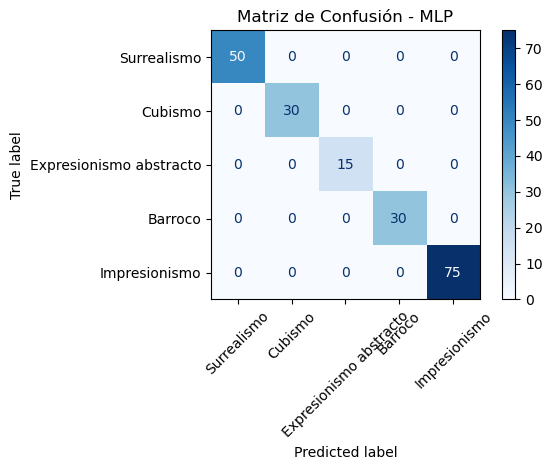


Reporte de clasificación:
                         precision    recall  f1-score   support

            Surrealismo      1.000     1.000     1.000        50
                Cubismo      1.000     1.000     1.000        30
Expresionismo abstracto      1.000     1.000     1.000        15
                Barroco      1.000     1.000     1.000        30
          Impresionismo      1.000     1.000     1.000        75

               accuracy                          1.000       200
              macro avg      1.000     1.000     1.000       200
           weighted avg      1.000     1.000     1.000       200



In [63]:
from sklearn.metrics import (
    accuracy_score,
    r2_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)
import matplotlib.pyplot as plt

# Predicciones en tu set completo de 200 imágenes
y_pred = best_mlp.predict(X)

# Accuracy
acc = accuracy_score(y, y_pred)
print("Accuracy:", acc)

# R² (no es tan común para clasificación, pero sí se puede pedir)
r2 = r2_score(y, y_pred)
print("R²:", r2)

# Matriz de Confusión
cm = confusion_matrix(y, y_pred)
print("\nMatriz de confusión:\n", cm)

# Visualizar matriz
class_names = ["Surrealismo", "Cubismo", "Expresionismo abstracto", "Barroco", "Impresionismo"]

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap="Blues", xticks_rotation=45)
plt.title("Matriz de Confusión - MLP")
plt.tight_layout()
plt.show()

# Reporte detallado
print("\nReporte de clasificación:")
print(classification_report(y, y_pred, digits=3, target_names=class_names))


In [64]:
from sklearn.model_selection import train_test_split

# X, y ya definidos
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,        # 20% para test (40 imágenes si tienes 200)
    stratify=y,
    random_state=123
)

print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)


(160, 53) (160,)
(40, 53) (40,)


In [65]:
print(grid.best_params_)


{'clf__activation': 'tanh', 'clf__alpha': 0.0001, 'clf__hidden_layer_sizes': (32,)}


In [66]:
{
    'clf__hidden_layer_sizes': (32,),
    'clf__activation': 'relu',
    'clf__alpha': 0.0001
}


{'clf__hidden_layer_sizes': (32,),
 'clf__activation': 'relu',
 'clf__alpha': 0.0001}

In [67]:
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

# Mismo SMOTE
smote = SMOTE(random_state=42, k_neighbors=3)

pipe_final = Pipeline([
    ("scaler", StandardScaler()),
    ("smote", smote),
    ("clf", MLPClassifier(
        max_iter=1000,
        random_state=42
    ))
])

# Aplicar los mejores hiperparámetros encontrados en el grid
pipe_final.set_params(**grid.best_params_)

# Entrenar SOLO con train
pipe_final.fit(X_train, y_train)


,steps,"[('scaler', ...), ('smote', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,sampling_strategy,'auto'
,random_state,42
,k_neighbors,3
,hidden_layer_sizes,"(32,)"


Accuracy (test): 0.725
F1 macro (test): 0.652063492063492

Matriz de confusión (test):
 [[ 8  0  2  0  0]
 [ 2  1  1  1  1]
 [ 0  0  3  0  0]
 [ 0  1  0  5  0]
 [ 0  1  0  2 12]]


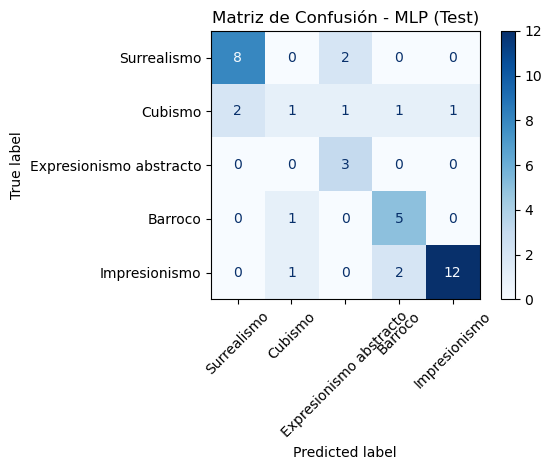


Reporte de clasificación (test):
                         precision    recall  f1-score   support

            Surrealismo      0.800     0.800     0.800        10
                Cubismo      0.333     0.167     0.222         6
Expresionismo abstracto      0.500     1.000     0.667         3
                Barroco      0.625     0.833     0.714         6
          Impresionismo      0.923     0.800     0.857        15

               accuracy                          0.725        40
              macro avg      0.636     0.720     0.652        40
           weighted avg      0.727     0.725     0.712        40



In [68]:
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)
import matplotlib.pyplot as plt

# Predicciones en el set de TEST (nunca visto por este modelo)
y_pred_test = pipe_final.predict(X_test)

# Accuracy y F1
acc_test = accuracy_score(y_test, y_pred_test)
f1_macro_test = f1_score(y_test, y_pred_test, average="macro")

print("Accuracy (test):", acc_test)
print("F1 macro (test):", f1_macro_test)

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred_test)
class_names = ["Surrealismo", "Cubismo", "Expresionismo abstracto", "Barroco", "Impresionismo"]

print("\nMatriz de confusión (test):\n", cm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap="Blues", xticks_rotation=45)
plt.title("Matriz de Confusión - MLP (Test)")
plt.tight_layout()
plt.show()

# Reporte detallado
print("\nReporte de clasificación (test):")
print(classification_report(y_test, y_pred_test, digits=3, target_names=class_names))


In [69]:
pipe_final.fit(X_train, y_train)


,steps,"[('scaler', ...), ('smote', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,sampling_strategy,'auto'
,random_state,42
,k_neighbors,3
,hidden_layer_sizes,"(32,)"


Iteraciones realizadas: 455


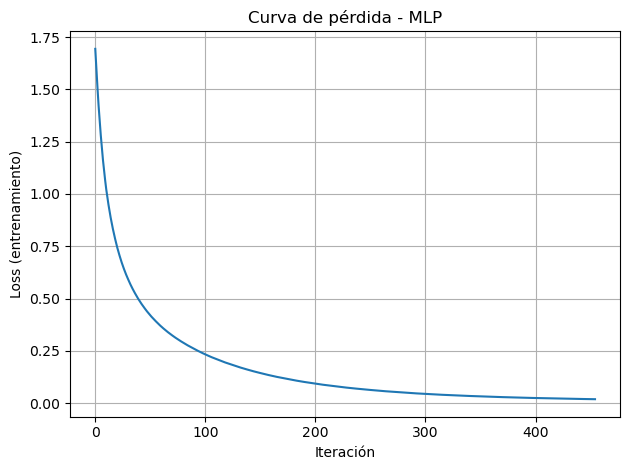

In [70]:
import matplotlib.pyplot as plt

clf = pipe_final.named_steps["clf"]   # el MLP dentro del pipeline

print("Iteraciones realizadas:", clf.n_iter_)

plt.plot(clf.loss_curve_)
plt.xlabel("Iteración")
plt.ylabel("Loss (entrenamiento)")
plt.title("Curva de pérdida - MLP")
plt.grid(True)
plt.tight_layout()
plt.show()


Entrenado a pintor 

In [71]:
import numpy as np
from sklearn.preprocessing import LabelEncoder

# X ya lo tienes (features numéricos)
# df tiene columnas 'painter' y 'label' (género 0–4)

# Target 1: pintor (11 clases)
le_painter = LabelEncoder()
y_painter = le_painter.fit_transform(df["painter"])

# Target 2: género directo (0–4) para evaluar después
y_genre = df["label"].to_numpy(dtype=int)

# Diccionarios pintor -> género -> label
painter_to_genre = {
    "Joan_Miro": "Surrealismo",
    "Salvador_Dali": "Surrealismo",
    "Rene_Magritte": "Surrealismo",
    "Pablo_Picasso": "Cubismo",
    "Jackson_Pollock": "Expresionismo abstracto",
    "Rembrandt": "Barroco",
    "Caravaggio": "Barroco",
    "Camille_Pissarro": "Impresionismo",
    "Alfred_Sisley": "Impresionismo",
    "Claude_Monet": "Impresionismo",
    "Vincent_van_Gogh": "Impresionismo",
}

genre_to_label = {
    "Surrealismo": 0,
    "Cubismo": 1,
    "Expresionismo abstracto": 2,
    "Barroco": 3,
    "Impresionismo": 4,
}

def painters_to_genre_labels(painter_ids: np.ndarray) -> np.ndarray:
    # de id numérico -> nombre de pintor
    names = le_painter.inverse_transform(painter_ids)
    # de pintor -> género -> label 0–4
    labels = [genre_to_label[painter_to_genre[n]] for n in names]
    return np.array(labels, dtype=int)


In [72]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train_p, y_test_p, y_train_g, y_test_g = train_test_split(
    X,
    y_painter,
    y_genre,
    test_size=0.2,
    stratify=y_painter,   # estratificas por pintor
    random_state=123
)

print("Train:", X_train.shape, "Test:", X_test.shape)


Train: (160, 53) Test: (40, 53)


In [73]:
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

# Pipeline base: scaler + SMOTE + MLP
smote = SMOTE(random_state=42, k_neighbors=3)

pipe_mlp_painter = Pipeline([
    ("scaler", StandardScaler()),
    ("smote", smote),
    ("clf", MLPClassifier(
        max_iter=1000,
        random_state=42,
        early_stopping=True,   # opcional pero nice
    ))
])

# Hiperparámetros a buscar
param_grid_painter = {
    "clf__hidden_layer_sizes": [
        (32,),
        (48,),
        (32, 16),
    ],
    "clf__activation": ["relu", "tanh", "logistic"],
    "clf__alpha": [1e-4, 5e-4, 1e-3],
    "clf__learning_rate_init": [1e-4, 1e-3, 5e-3],
}

# Folds estratificados por pintor
cv_painter = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

grid_painter = GridSearchCV(
    estimator=pipe_mlp_painter,
    param_grid=param_grid_painter,
    scoring="f1_macro",   # F1 macro sobre los 11 pintores
    cv=cv_painter,
    n_jobs=-1,
    verbose=1
)

grid_painter.fit(X_train, y_train_p)

print("Mejores hiperparámetros (pintor):")
print(grid_painter.best_params_)
print("Mejor F1 macro (CV, pintor):", grid_painter.best_score_)


Fitting 5 folds for each of 81 candidates, totalling 405 fits
Mejores hiperparámetros (pintor):
{'clf__activation': 'tanh', 'clf__alpha': 0.0001, 'clf__hidden_layer_sizes': (48,), 'clf__learning_rate_init': 0.005}
Mejor F1 macro (CV, pintor): 0.38973107700380427


Accuracy (género vía pintor, test): 0.775
R² (género vía pintor, test): 0.16894977168949776
F1 macro (género vía pintor, test): 0.7758730158730158

Matriz de confusión (género vía pintor, test):
 [[ 5  0  1  2  2]
 [ 1  4  0  1  0]
 [ 0  0  3  0  0]
 [ 0  0  0  6  0]
 [ 2  0  0  0 13]]


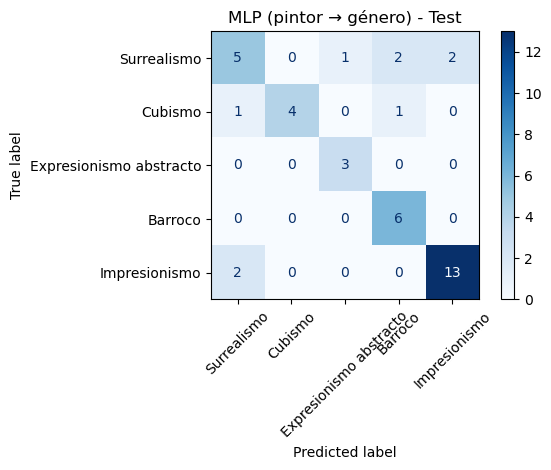


Reporte de clasificación (género vía pintor, test):
                         precision    recall  f1-score   support

            Surrealismo      0.625     0.500     0.556        10
                Cubismo      1.000     0.667     0.800         6
Expresionismo abstracto      0.750     1.000     0.857         3
                Barroco      0.667     1.000     0.800         6
          Impresionismo      0.867     0.867     0.867        15

               accuracy                          0.775        40
              macro avg      0.782     0.807     0.776        40
           weighted avg      0.787     0.775     0.768        40



In [74]:
from sklearn.metrics import (
    accuracy_score,
    r2_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)
import matplotlib.pyplot as plt

# Mejor pipeline (scaler + SMOTE + MLP) entrenado en X_train, y_train_p
best_painter_clf = grid_painter.best_estimator_

# Predicción de PINTOR en el set de TEST
y_pred_p_test = best_painter_clf.predict(X_test)

# Mapear pintor -> género (label 0–4)
y_pred_genre_from_painter = painters_to_genre_labels(y_pred_p_test)

# Métricas a nivel GÉNERO
acc = accuracy_score(y_test_g, y_pred_genre_from_painter)
r2  = r2_score(y_test_g, y_pred_genre_from_painter)
f1m = f1_score(y_test_g, y_pred_genre_from_painter, average="macro")

print("Accuracy (género vía pintor, test):", acc)
print("R² (género vía pintor, test):", r2)
print("F1 macro (género vía pintor, test):", f1m)

# Matriz de confusión
cm = confusion_matrix(y_test_g, y_pred_genre_from_painter)

class_names = ["Surrealismo", "Cubismo", "Expresionismo abstracto", "Barroco", "Impresionismo"]

print("\nMatriz de confusión (género vía pintor, test):\n", cm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap="Blues", xticks_rotation=45)
plt.title("MLP (pintor → género) - Test")
plt.tight_layout()
plt.show()

print("\nReporte de clasificación (género vía pintor, test):")
print(classification_report(
    y_test_g,
    y_pred_genre_from_painter,
    digits=3,
    target_names=class_names
))


Iteraciones realizadas: 455


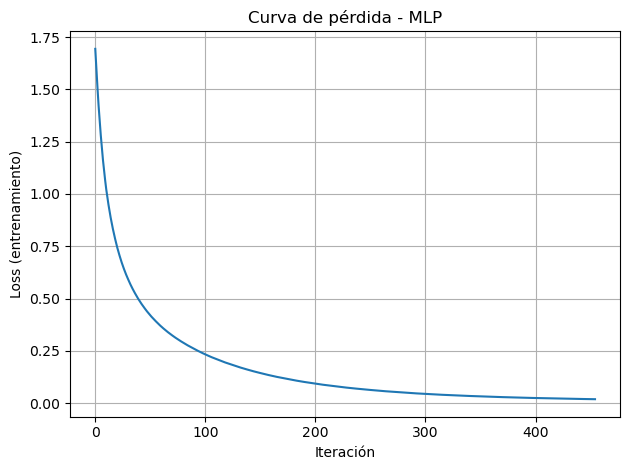

In [75]:
import matplotlib.pyplot as plt

clf = pipe_final.named_steps["clf"]   # el MLP dentro del pipeline

print("Iteraciones realizadas:", clf.n_iter_)

plt.plot(clf.loss_curve_)
plt.xlabel("Iteración")
plt.ylabel("Loss (entrenamiento)")
plt.title("Curva de pérdida - MLP")
plt.grid(True)
plt.tight_layout()
plt.show()


In [76]:
import matplotlib.pyplot as plt

def plot_mlp_curves(pipeline, titulo="MLP"):
    """
    pipeline: Pipeline ya entrenado (fit) que contiene un MLPClassifier
              en pipeline.named_steps["clf"].
    """
    clf = pipeline.named_steps["clf"]

    # Curva de pérdida de entrenamiento
    loss_curve = getattr(clf, "loss_curve_", None)

    if loss_curve is None:
        print("Este MLP no tiene 'loss_curve_'. ¿Seguro que se entrenó?")
        return

    plt.figure(figsize=(6, 4))
    plt.plot(loss_curve, label="Train loss")

    # Si hay validación interna por early_stopping, la graficamos también
    val_scores = getattr(clf, "validation_scores_", None)
    if val_scores is not None:
        # validation_scores_ son scores (por default accuracy) → los pasamos a 'val loss' aproximada
        # o simplemente los graficamos como 'val score'
        ax1 = plt.gca()
        ax2 = ax1.twinx()
        ax2.plot(val_scores, color="orange", label="Val score (internal)", linestyle="--")
        ax2.set_ylabel("Validation score")
        ax2.legend(loc="lower right")
        ax1.set_ylabel("Train loss")
        ax1.set_xlabel("Época")
        ax1.set_title(f"Curva de entrenamiento - {titulo}")
        ax1.grid(True)
        plt.tight_layout()
        plt.show()
    else:
        plt.xlabel("Época")
        plt.ylabel("Train loss")
        plt.title(f"Curva de pérdida - {titulo}")
        plt.grid(True)
        plt.legend()
        plt.tight_layout()
        plt.show()


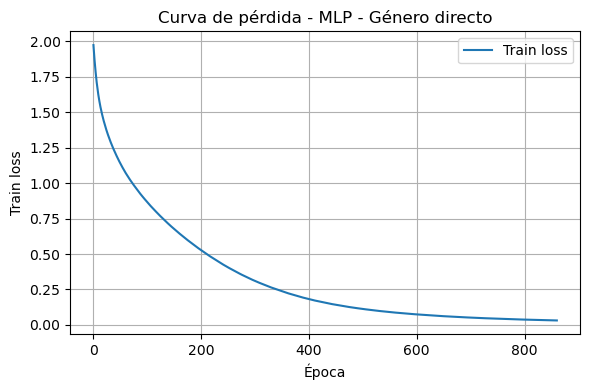

In [77]:
pipe_final.fit(X_train, y_train)  # ya lo tenías

plot_mlp_curves(pipe_final, titulo="MLP - Género directo")


In [78]:
best_painter_clf = grid_painter.best_estimator_
best_painter_clf.fit(X_train, y_train_p)


,steps,"[('scaler', ...), ('smote', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,sampling_strategy,'auto'
,random_state,42
,k_neighbors,3
,hidden_layer_sizes,"(48,)"


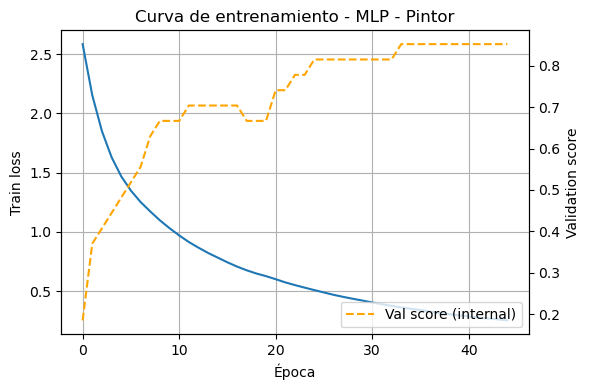

In [79]:
plot_mlp_curves(best_painter_clf, titulo="MLP - Pintor")


In [80]:
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42, k_neighbors=3)

pipe_final = Pipeline([
    ("scaler", StandardScaler()),
    ("smote", smote),
    ("clf", MLPClassifier(
        hidden_layer_sizes=(32,),      # o lo que te dio el grid
        activation="relu",             # idem
        alpha=1e-4,                    # idem
        max_iter=1000,
        early_stopping=True,           # 👈 importante
        n_iter_no_change=10,
        random_state=42,
    )),
])

pipe_final.fit(X_train, y_train)   # ya lo tienes así


,steps,"[('scaler', ...), ('smote', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,sampling_strategy,'auto'
,random_state,42
,k_neighbors,3
,hidden_layer_sizes,"(32,)"


Iteraciones realizadas: 30


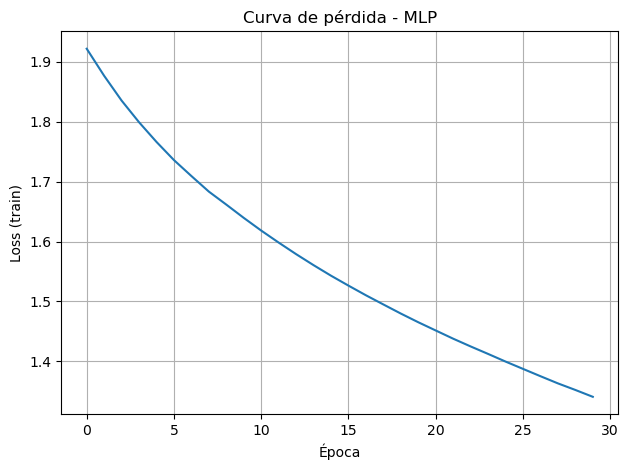

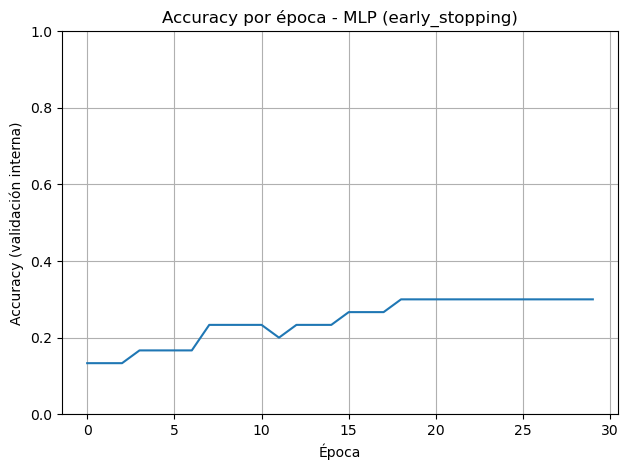

In [81]:
import matplotlib.pyplot as plt

clf = pipe_final.named_steps["clf"]

print("Iteraciones realizadas:", clf.n_iter_)

# Curva de loss (por si también la quieres)
plt.figure()
plt.plot(clf.loss_curve_)
plt.xlabel("Época")
plt.ylabel("Loss (train)")
plt.title("Curva de pérdida - MLP")
plt.grid(True)
plt.tight_layout()
plt.show()

# ✅ Curva de accuracy en validación por época
if hasattr(clf, "validation_scores_"):
    plt.figure()
    plt.plot(clf.validation_scores_)
    plt.xlabel("Época")
    plt.ylabel("Accuracy (validación interna)")
    plt.title("Accuracy por época - MLP (early_stopping)")
    plt.ylim(0, 1)
    plt.grid(True)
    plt.tight_layout()
    plt.show()
else:
    print("El MLP no tiene 'validation_scores_'. Asegúrate de usar early_stopping=True.")


Entrenada por piuntor + boosting 

Train: (160, 53) Test: (40, 53)
Fitting 5 folds for each of 180 candidates, totalling 900 fits
Mejores hiperparámetros (pintor):
{'clf__activation': 'tanh', 'clf__alpha': 0.0001, 'clf__hidden_layer_sizes': (48,), 'clf__learning_rate_init': 0.005}
Mejor F1 macro (CV, pintor): 0.44682014954742233


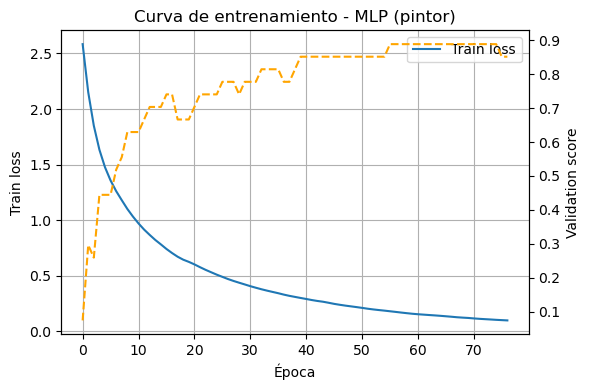


=== Métricas en TEST (género vía pintor) ===
Accuracy: 0.75
R²: 0.3881278538812786
F1 macro: 0.7144086021505377

Matriz de confusión (género vía pintor, test):
 [[ 6  1  0  2  1]
 [ 1  3  1  0  1]
 [ 0  0  2  0  1]
 [ 0  0  0  6  0]
 [ 1  0  0  1 13]]


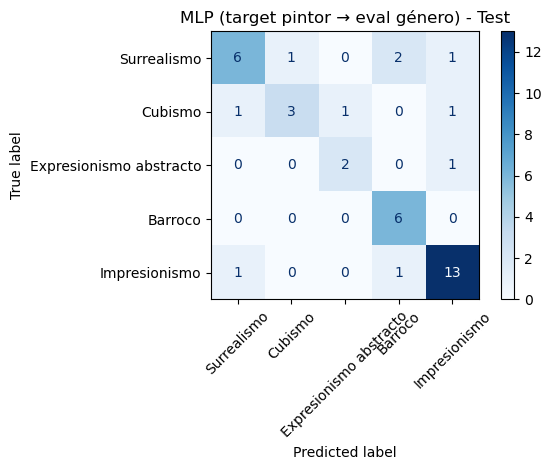


Reporte de clasificación (género vía pintor, test):
                         precision    recall  f1-score   support

            Surrealismo      0.750     0.600     0.667        10
                Cubismo      0.750     0.500     0.600         6
Expresionismo abstracto      0.667     0.667     0.667         3
                Barroco      0.667     1.000     0.800         6
          Impresionismo      0.812     0.867     0.839        15

               accuracy                          0.750        40
              macro avg      0.729     0.727     0.714        40
           weighted avg      0.755     0.750     0.741        40



In [82]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.metrics import (
    accuracy_score,
    r2_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline

# ============================
# 0) Targets y mapeos
# ============================

# Target 1: pintor (11 clases)
le_painter = LabelEncoder()
y_painter = le_painter.fit_transform(df["painter"])

# Target 2: género directo (0–4) para evaluar después
y_genre = df["label"].to_numpy(dtype=int)

# Diccionarios pintor -> género -> label (según tu tabla)
painter_to_genre = {
    "Joan_Miro": "Surrealismo",
    "Salvador_Dali": "Surrealismo",
    "Rene_Magritte": "Surrealismo",
    "Pablo_Picasso": "Cubismo",
    "Jackson_Pollock": "Expresionismo abstracto",
    "Rembrandt": "Barroco",
    "Caravaggio": "Barroco",
    "Camille_Pissarro": "Impresionismo",
    "Alfred_Sisley": "Impresionismo",
    "Claude_Monet": "Impresionismo",
    "Vincent_van_Gogh": "Impresionismo",
}

genre_to_label = {
    "Surrealismo": 0,
    "Cubismo": 1,
    "Expresionismo abstracto": 2,
    "Barroco": 3,
    "Impresionismo": 4,
}

def painters_to_genre_labels(painter_ids: np.ndarray) -> np.ndarray:
    """Convierte predicciones de pintor (enteros) a labels de género 0–4."""
    names = le_painter.inverse_transform(painter_ids)
    labels = [genre_to_label[painter_to_genre[n]] for n in names]
    return np.array(labels, dtype=int)

# ============================
# 1) Train / Test split (estratificado por pintor)
# ============================

X_train, X_test, y_train_p, y_test_p, y_train_g, y_test_g = train_test_split(
    X,
    y_painter,
    y_genre,
    test_size=0.2,
    stratify=y_painter,     # estratificamos por pintor
    random_state=123
)

print("Train:", X_train.shape, "Test:", X_test.shape)

# ============================
# 2) Pipeline + GridSearchCV (target = pintor)
# ============================

smote = SMOTE(random_state=42, k_neighbors=1)

pipe_mlp_painter = Pipeline([
    ("scaler", StandardScaler()),
    ("smote", smote),
    ("clf", MLPClassifier(
        max_iter=1000,
        random_state=42,
        early_stopping=True,    # validación interna para evitar overfitting
        n_iter_no_change=20,
        solver="adam"
    ))
])

# Búsqueda un poco "boosted" pero razonable para tu tamaño de datos
param_grid_painter = {
    "clf__hidden_layer_sizes": [
        (32,),
        (48,),
        (64,),
        (48, 24),
        (64, 32),
    ],
    "clf__activation": ["relu", "tanh", "logistic"],
    "clf__alpha": [1e-4, 5e-4, 1e-3, 1e-2],
    "clf__learning_rate_init": [1e-4, 1e-3, 5e-3],
}

cv_painter = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

grid_painter = GridSearchCV(
    estimator=pipe_mlp_painter,
    param_grid=param_grid_painter,
    scoring="f1_macro",      # F1 macro sobre las 11 clases de pintor
    cv=cv_painter,
    n_jobs=-1,
    verbose=1
)

grid_painter.fit(X_train, y_train_p)

print("Mejores hiperparámetros (pintor):")
print(grid_painter.best_params_)
print("Mejor F1 macro (CV, pintor):", grid_painter.best_score_)

# ============================
# 3) Modelo final (pintor) y curva de pérdida
# ============================

best_painter_clf = grid_painter.best_estimator_   # Pipeline ya con los mejores params
best_painter_clf.fit(X_train, y_train_p)          # reentrenar explícitamente en todo el train

# Curva de pérdida del MLP (train) y score de validación interna
clf_inner = best_painter_clf.named_steps["clf"]

plt.figure(figsize=(6, 4))
plt.plot(clf_inner.loss_curve_, label="Train loss")
if hasattr(clf_inner, "validation_scores_"):
    ax1 = plt.gca()
    ax2 = ax1.twinx()
    ax2.plot(clf_inner.validation_scores_, color="orange",
             linestyle="--", label="Val score (internal)")
    ax1.set_ylabel("Train loss")
    ax2.set_ylabel("Validation score")
    ax1.set_xlabel("Época")
    plt.title("Curva de entrenamiento - MLP (pintor)")
    ax1.grid(True)
    ax1.legend(loc="upper right")
else:
    plt.xlabel("Época")
    plt.ylabel("Train loss")
    plt.title("Curva de pérdida - MLP (pintor)")
    plt.grid(True)
plt.tight_layout()
plt.show()

# ============================
# 4) Evaluación en TEST a nivel GÉNERO
# ============================

# Predicción de PINTOR en el set de TEST
y_pred_p_test = best_painter_clf.predict(X_test)

# Mapeo pintor -> género (labels 0–4)
y_pred_g_test = painters_to_genre_labels(y_pred_p_test)

# Métricas a nivel género
acc = accuracy_score(y_test_g, y_pred_g_test)
r2  = r2_score(y_test_g, y_pred_g_test)
f1m = f1_score(y_test_g, y_pred_g_test, average="macro")

print("\n=== Métricas en TEST (género vía pintor) ===")
print("Accuracy:", acc)
print("R²:", r2)
print("F1 macro:", f1m)

# Matriz de confusión
cm = confusion_matrix(y_test_g, y_pred_g_test)
class_names = ["Surrealismo", "Cubismo",
               "Expresionismo abstracto", "Barroco", "Impresionismo"]

print("\nMatriz de confusión (género vía pintor, test):\n", cm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap="Blues", xticks_rotation=45)
plt.title("MLP (target pintor → eval género) - Test")
plt.tight_layout()
plt.show()

print("\nReporte de clasificación (género vía pintor, test):")
print(classification_report(
    y_test_g,
    y_pred_g_test,
    digits=3,
    target_names=class_names
))
